In [ ]:
# ============================================================
# CELL 1 : IMPORT LIBRARIES
# Project:
# Autonomous Vacuum Cleaner Navigation for Efficient Room Coverage
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import warnings

from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

# -------------------------------
# Random Seed (Reproducibility)
# -------------------------------

np.random.seed(42)
random.seed(42)

# -------------------------------
# Plot Settings
# -------------------------------

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["figure.dpi"] = 120

print("="*60)
print("Autonomous Vacuum Cleaner Navigation")
print("Bellman Equation using Value Iteration")
print("="*60)

print("\nLibraries Loaded Successfully.")

Autonomous Vacuum Cleaner Navigation
Bellman Equation using Value Iteration

Libraries Loaded Successfully.


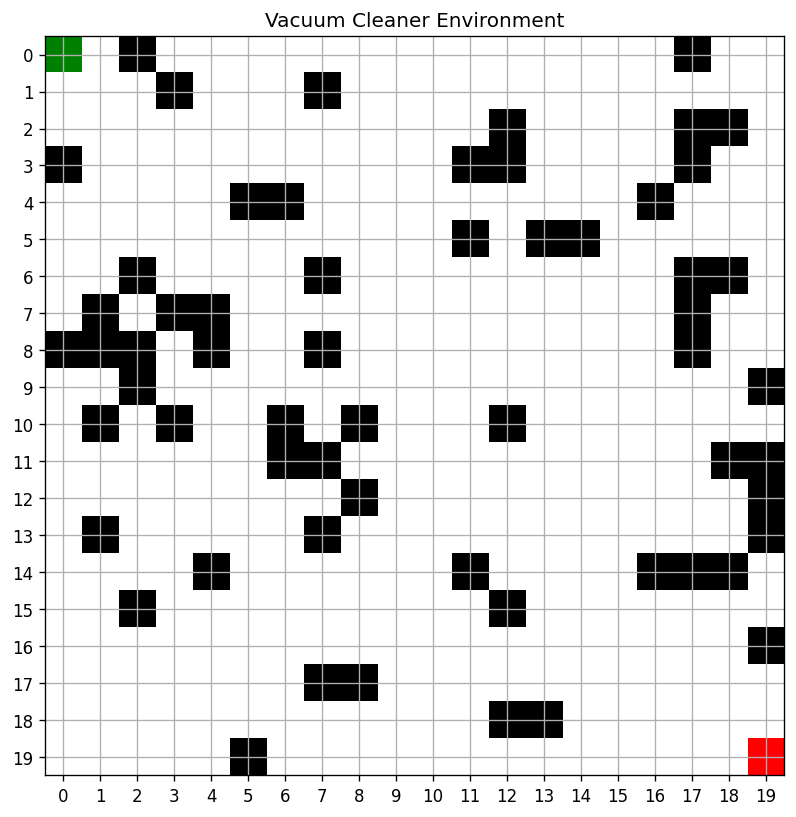


Environment Summary

             Parameter     Value
0            Grid Size   20 x 20
1          Total Cells       400
2  Obstacle Percentage       15%
3  Number of Obstacles        60
4           Free Cells       340
5      Discount Factor       0.9
6       Start Position    (0, 0)
7        Goal Position  (19, 19)


In [ ]:
# ============================================================
# CELL 2 : ENVIRONMENT SETUP
# ============================================================

# -----------------------------
# Grid Configuration
# -----------------------------
GRID_SIZE = 20

FREE = 0
OBSTACLE = 1
START = 2
GOAL = 3

START_POS = (0, 0)
GOAL_POS = (GRID_SIZE - 1, GRID_SIZE - 1)

# -----------------------------
# Reward Model (MDP)
# -----------------------------
REWARD_NEW_CELL = 10
REWARD_GOAL = 100

PENALTY_MOVE = -1
PENALTY_REVISIT = -5
PENALTY_OBSTACLE = -20
PENALTY_BOUNDARY = -15

GAMMA = 0.90

# -----------------------------
# Actions
# -----------------------------
ACTIONS = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1)
}

# -----------------------------
# Create Environment
# -----------------------------
environment = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

# -----------------------------
# Generate Obstacles
# -----------------------------
OBSTACLE_PERCENTAGE = 0.15

num_obstacles = int(GRID_SIZE * GRID_SIZE * OBSTACLE_PERCENTAGE)

obstacles = []

while len(obstacles) < num_obstacles:

    x = random.randint(0, GRID_SIZE - 1)
    y = random.randint(0, GRID_SIZE - 1)

    if (x, y) != START_POS and (x, y) != GOAL_POS:

        if (x, y) not in obstacles:

            obstacles.append((x, y))
            environment[x, y] = OBSTACLE

# -----------------------------
# Initialize Value Function
# -----------------------------
value_function = np.zeros((GRID_SIZE, GRID_SIZE))

policy = np.full((GRID_SIZE, GRID_SIZE), "", dtype=object)

# -----------------------------
# Helper Function
# -----------------------------
def is_valid(x, y):

    if x < 0 or x >= GRID_SIZE:
        return False

    if y < 0 or y >= GRID_SIZE:
        return False

    if environment[x, y] == OBSTACLE:
        return False

    return True

# -----------------------------
# Display Environment
# -----------------------------
plot_grid = environment.copy()

plot_grid[START_POS] = START
plot_grid[GOAL_POS] = GOAL

cmap = ListedColormap([
    "white",      # Free Cell
    "black",      # Obstacle
    "green",      # Start
    "red"         # Goal
])

plt.figure(figsize=(8,8))

plt.imshow(plot_grid, cmap=cmap)

plt.title("Vacuum Cleaner Environment")

plt.xticks(range(GRID_SIZE))
plt.yticks(range(GRID_SIZE))

plt.grid(True)

plt.show()

# -----------------------------
# Summary Table
# -----------------------------
environment_summary = pd.DataFrame({

    "Parameter":[
        "Grid Size",
        "Total Cells",
        "Obstacle Percentage",
        "Number of Obstacles",
        "Free Cells",
        "Discount Factor",
        "Start Position",
        "Goal Position"
    ],

    "Value":[
        f"{GRID_SIZE} x {GRID_SIZE}",
        GRID_SIZE*GRID_SIZE,
        f"{OBSTACLE_PERCENTAGE*100:.0f}%",
        len(obstacles),
        GRID_SIZE*GRID_SIZE-len(obstacles),
        GAMMA,
        START_POS,
        GOAL_POS
    ]

})

print("\nEnvironment Summary\n")
print(environment_summary)

In [ ]:
# ============================================================
# CELL 3 : MDP TRANSITION MODEL & BELLMAN EQUATION SETUP
# ============================================================

# ------------------------------------------------------------
# State Space
# Each state represents robot position (x,y)
# ------------------------------------------------------------

states = []

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):

        if environment[i, j] != OBSTACLE:
            states.append((i, j))


print("Total States :", len(states))


# ------------------------------------------------------------
# Transition Function
# ------------------------------------------------------------

def transition(state, action):

    x, y = state

    dx, dy = ACTIONS[action]

    new_x = x + dx
    new_y = y + dy


    # Boundary condition
    if new_x < 0 or new_x >= GRID_SIZE or new_y < 0 or new_y >= GRID_SIZE:

        return state, PENALTY_BOUNDARY


    # Obstacle condition
    if environment[new_x, new_y] == OBSTACLE:

        return state, PENALTY_OBSTACLE


    # Goal condition
    if (new_x, new_y) == GOAL_POS:

        return (new_x, new_y), REWARD_GOAL


    # Normal movement
    return (new_x, new_y), PENALTY_MOVE



# ------------------------------------------------------------
# Bellman Equation
#
# V(s) = max [ R(s,a) + γV(s') ]
#
# ------------------------------------------------------------


def bellman_update(value_function):

    new_value = value_function.copy()


    for state in states:

        x, y = state


        action_values = []


        for action in ACTIONS:


            next_state, reward = transition(state, action)


            nx, ny = next_state


            value = reward + GAMMA * value_function[nx, ny]


            action_values.append(value)


        new_value[x, y] = max(action_values)


    return new_value



# ------------------------------------------------------------
# Initial Value Function
# ------------------------------------------------------------

value_function = np.zeros((GRID_SIZE, GRID_SIZE))


print("\nMDP Model Created Successfully")

print("--------------------------------")

print("States :", len(states))

print("Actions :", list(ACTIONS.keys()))

print("Discount Factor :", GAMMA)

print("\nBellman Equation:")

print("V(s) = max [ R(s,a) + γV(s') ]")

Total States : 340

MDP Model Created Successfully
--------------------------------
States : 340
Actions : ['UP', 'DOWN', 'LEFT', 'RIGHT']
Discount Factor : 0.9

Bellman Equation:
V(s) = max [ R(s,a) + γV(s') ]


Starting Value Iteration...
------------------------------------------------------------
Value Iteration Converged
Iterations : 111
Error : 0.00093

Value Function Sample:
      0      1       2      3      4      5      6      7      8      9   \
0   0.77   1.97    0.00   4.78   6.42   8.25  10.28  12.53  15.03  17.82   
1   1.97   3.30    4.78   0.00   8.25  10.28  12.53   0.00  17.82  20.91   
2   3.30   4.78    6.42   8.25  10.28  12.53  15.03  17.82  20.91  24.34   
3   0.00   6.42    8.25  10.28  12.53  15.03  17.82  20.91  24.34  28.16   
4   6.42   8.25   10.28  12.53  15.03   0.00   0.00  24.34  28.16  32.40   
5   8.25  10.28   12.53  15.03  17.82  20.91  24.34  28.16  32.40  37.11   
6   6.42   8.25    0.00  17.82  20.91  24.34  28.16   0.00  37.11  42.34   
7   4.78   0.00 -200.00   0.00   0.00  28.16  32.40  37.11  42.34  48.16   
8   0.00   0.00    0.00  24.34   0.00  32.40  37.11   0.00  48.16  54.62   
9  17.82  15.03    0.00  28.16  32.40  37.11  42.34  48.16  54.62  6

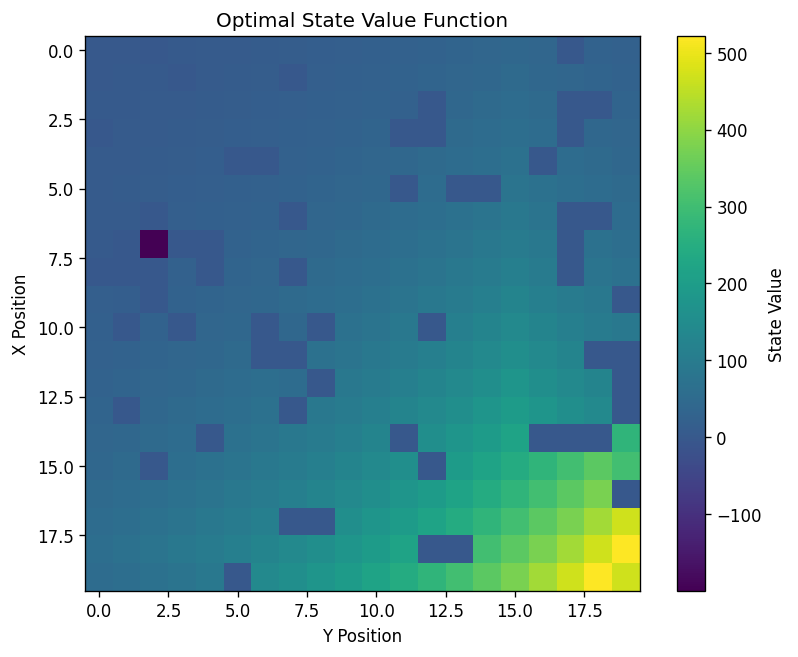


Optimal Policy Generated Successfully


In [ ]:
# ============================================================
# CELL 4 : VALUE ITERATION & OPTIMAL POLICY GENERATION
# ============================================================

MAX_ITERATIONS = 500
CONVERGENCE_THRESHOLD = 0.001


print("Starting Value Iteration...")
print("-"*60)


for iteration in range(MAX_ITERATIONS):

    old_value = value_function.copy()

    # Bellman Update
    value_function = bellman_update(value_function)


    # Calculate convergence error
    error = np.max(np.abs(value_function - old_value))


    if error < CONVERGENCE_THRESHOLD:

        print("Value Iteration Converged")

        print("Iterations :", iteration + 1)

        print("Error :", round(error,5))

        break


else:

    print("Maximum iterations completed")



# ============================================================
# Generate Optimal Policy
# ============================================================

policy = np.full((GRID_SIZE, GRID_SIZE), "", dtype=object)


for state in states:

    x, y = state

    best_action = None

    best_value = -float("inf")


    for action in ACTIONS:


        next_state, reward = transition(state, action)

        nx, ny = next_state


        action_value = reward + GAMMA * value_function[nx, ny]


        if action_value > best_value:

            best_value = action_value

            best_action = action


    policy[x,y] = best_action



# Goal State

policy[GOAL_POS] = "GOAL"



# ============================================================
# Display Value Function
# ============================================================

print("\nValue Function Sample:")

value_table = pd.DataFrame(
    np.round(value_function,2)
)

print(value_table.head(10))



# ============================================================
# Display Policy
# ============================================================

print("\nOptimal Policy Sample:")

policy_table = pd.DataFrame(policy)

print(policy_table.head(10))



# ============================================================
# Visualize Value Function
# ============================================================

plt.figure(figsize=(8,6))

plt.imshow(value_function, cmap="viridis")

plt.colorbar(label="State Value")

plt.title("Optimal State Value Function")

plt.xlabel("Y Position")

plt.ylabel("X Position")

plt.show()


print("\nOptimal Policy Generated Successfully")

In [ ]:
# ============================================================
# CELL 5 : VACUUM CLEANER SIMULATION
# REWARD + PENALTY TRACKING
# ============================================================

MAX_STEPS = 200

current_position = START_POS

visited_cells = set()

navigation_history = []

battery = 100

total_reward = 0
total_penalty = 0


print("Starting Vacuum Cleaner Simulation")
print("-"*60)


for step in range(MAX_STEPS):

    x, y = current_position


    # Stop if goal reached

    if current_position == GOAL_POS:

        print("Goal Reached!")

        break


    # ------------------------------------------------
    # Select Action
    # ------------------------------------------------

    action = policy[x, y]


    # If no policy available

    if action == "":

        action = random.choice(list(ACTIONS.keys()))


    # Exploration to generate penalties

    if random.random() < 0.20:

        action = random.choice(list(ACTIONS.keys()))



    # ------------------------------------------------
    # Calculate Next Position
    # ------------------------------------------------

    dx, dy = ACTIONS[action]

    new_x = x + dx
    new_y = y + dy



    reward = 0
    penalty = 0



    # ------------------------------------------------
    # Boundary Penalty
    # ------------------------------------------------

    if new_x < 0 or new_x >= GRID_SIZE or new_y < 0 or new_y >= GRID_SIZE:

        next_position = current_position

        penalty = PENALTY_BOUNDARY



    # ------------------------------------------------
    # Obstacle Penalty
    # ------------------------------------------------

    elif environment[new_x, new_y] == OBSTACLE:

        next_position = current_position

        penalty = PENALTY_OBSTACLE



    else:

        next_position = (new_x, new_y)


        # ------------------------------------------------
        # Goal Reward
        # ------------------------------------------------

        if next_position == GOAL_POS:

            reward = REWARD_GOAL


        # ------------------------------------------------
        # Revisit Penalty
        # ------------------------------------------------

        elif next_position in visited_cells:

            penalty = PENALTY_REVISIT


        # ------------------------------------------------
        # New Cell Cleaning Reward
        # ------------------------------------------------

        else:

            reward = REWARD_NEW_CELL



    # ------------------------------------------------
    # Update Values
    # ------------------------------------------------

    net_reward = reward + penalty


    total_reward += reward

    total_penalty += penalty



    battery -= 1

    if battery < 0:

        battery = 0



    visited_cells.add(next_position)



    coverage = len(visited_cells)



    # ------------------------------------------------
    # Store Simulation Record
    # ------------------------------------------------

    navigation_history.append({

        "Step": step,

        "X_Position": next_position[0],

        "Y_Position": next_position[1],

        "Action": action,

        "State":

            "Goal" if next_position == GOAL_POS

            else "Obstacle" if penalty == PENALTY_OBSTACLE

            else "Boundary" if penalty == PENALTY_BOUNDARY

            else "Revisited" if penalty == PENALTY_REVISIT

            else "Cleaned Cell",


        "Reward": reward,

        "Penalty": penalty,

        "Net_Reward": net_reward,

        "Cumulative_Reward": total_reward + total_penalty,

        "Battery": battery,

        "Coverage": coverage

    })



    current_position = next_position



print("\nSimulation Completed")
print("-"*60)

print("Steps Taken :", len(navigation_history))

print("Total Reward :", total_reward)

print("Total Penalty :", total_penalty)

print("Net Reward :", total_reward + total_penalty)

print("Coverage Cells :", len(visited_cells))

print("Battery Remaining :", battery,"%")

Starting Vacuum Cleaner Simulation
------------------------------------------------------------
Goal Reached!

Simulation Completed
------------------------------------------------------------
Steps Taken : 54
Total Reward : 570
Total Penalty : -30
Net Reward : 540
Coverage Cells : 48
Battery Remaining : 46 %


In [ ]:
# ============================================================
# CELL 6 : DATASET GENERATION
# ============================================================

# Convert navigation history into DataFrame

vacuum_df = pd.DataFrame(navigation_history)


# ------------------------------------------------------------
# Display Dataset
# ------------------------------------------------------------

print("="*70)
print("AUTONOMOUS VACUUM CLEANER SIMULATION DATASET")
print("="*70)


vacuum_df.head(15)

AUTONOMOUS VACUUM CLEANER SIMULATION DATASET


,Step,X_Position,Y_Position,Action,State,Reward,Penalty,Net_Reward,Cumulative_Reward,Battery,Coverage
0,0,1,0,DOWN,Cleaned Cell,10,0,10,10,99,1
1,1,0,0,UP,Cleaned Cell,10,0,10,20,98,2
2,2,1,0,DOWN,Revisited,0,-5,-5,15,97,2
3,3,2,0,DOWN,Cleaned Cell,10,0,10,25,96,3
4,4,2,1,RIGHT,Cleaned Cell,10,0,10,35,95,4
5,5,3,1,DOWN,Cleaned Cell,10,0,10,45,94,5
6,6,3,2,RIGHT,Cleaned Cell,10,0,10,55,93,6
7,7,2,2,UP,Cleaned Cell,10,0,10,65,92,7
8,8,3,2,DOWN,Revisited,0,-5,-5,60,91,7
9,9,4,2,DOWN,Cleaned Cell,10,0,10,70,90,8


In [ ]:
# ============================================================
# CELL 7 : PROFESSIONAL PERFORMANCE SUMMARY TABLE
# ============================================================


# -----------------------------
# Calculate Metrics
# -----------------------------

total_steps = len(vacuum_df)

total_reward = vacuum_df["Reward"].sum()

total_penalty = vacuum_df["Penalty"].sum()

net_reward = vacuum_df["Net_Reward"].sum()

battery_remaining = vacuum_df["Battery"].iloc[-1]


coverage_cells = vacuum_df["Coverage"].iloc[-1]

coverage_percentage = round(
    (coverage_cells / (GRID_SIZE * GRID_SIZE)) * 100,
    2
)


obstacle_hits = len(
    vacuum_df[vacuum_df["State"] == "Obstacle"]
)


boundary_hits = len(
    vacuum_df[vacuum_df["State"] == "Boundary"]
)


revisits = len(
    vacuum_df[vacuum_df["State"] == "Revisited"]
)


goal_status = (
    "Reached"
    if GOAL_POS in visited_cells
    else "Not Reached"
)



# -----------------------------
# Create Summary Table
# -----------------------------

performance_summary = pd.DataFrame({

    "Performance Metric":[

        "Environment Size",

        "Total Simulation Steps",

        "Coverage Cells",

        "Coverage Percentage",

        "Total Reward",

        "Total Penalty",

        "Net Reward",

        "Obstacle Collisions",

        "Boundary Violations",

        "Revisited Cells",

        "Battery Remaining",

        "Goal Status"

    ],


    "Value":[

        f"{GRID_SIZE} x {GRID_SIZE}",

        total_steps,

        coverage_cells,

        f"{coverage_percentage}%",

        total_reward,

        total_penalty,

        net_reward,

        obstacle_hits,

        boundary_hits,

        revisits,

        f"{battery_remaining}%",

        goal_status

    ]

})


# -----------------------------
# Display Table
# -----------------------------

print("="*70)

print("AUTONOMOUS VACUUM CLEANER PERFORMANCE SUMMARY")

print("="*70)


performance_summary

AUTONOMOUS VACUUM CLEANER PERFORMANCE SUMMARY


,Performance Metric,Value
0,Environment Size,20 x 20
1,Total Simulation Steps,54
2,Coverage Cells,48
3,Coverage Percentage,12.0%
4,Total Reward,570
5,Total Penalty,-30
6,Net Reward,540
7,Obstacle Collisions,0
8,Boundary Violations,0
9,Revisited Cells,6


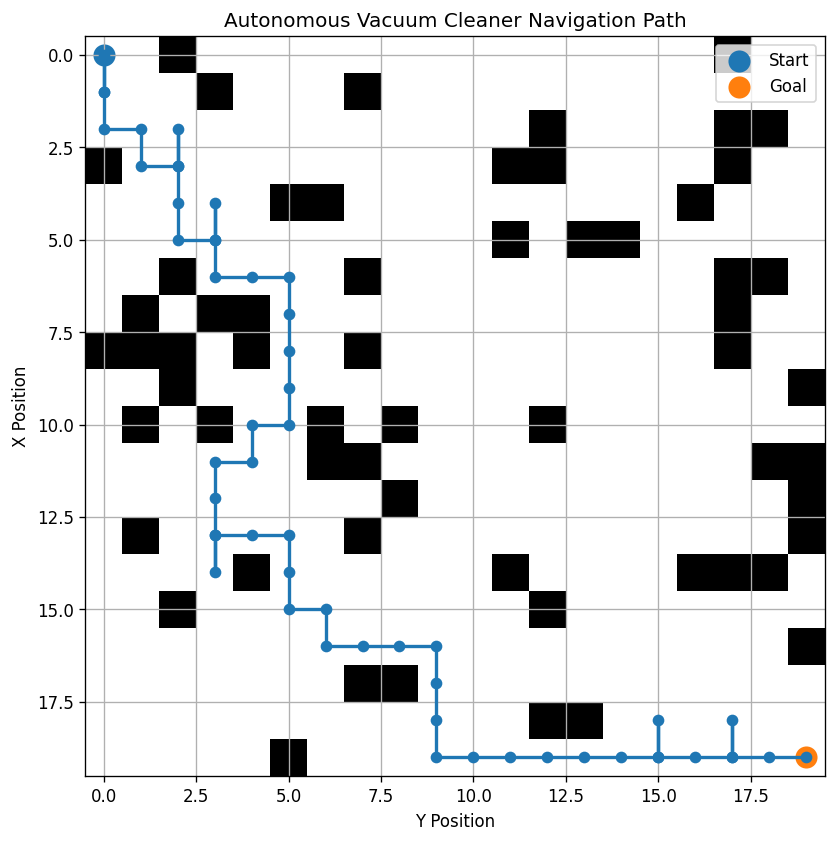

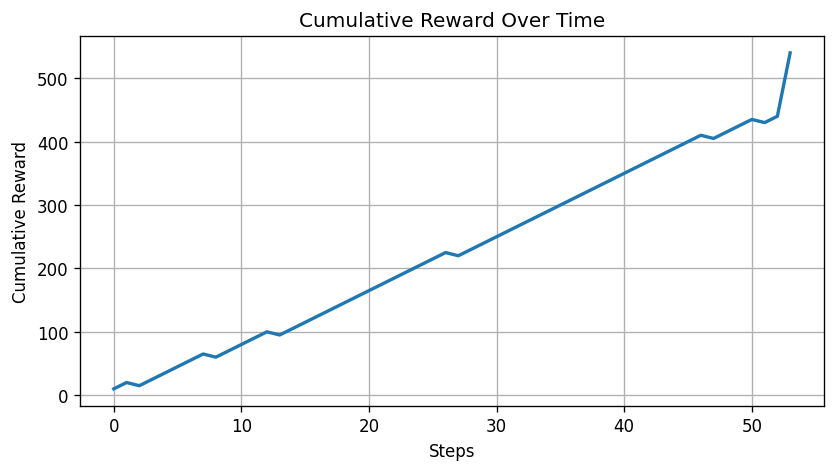

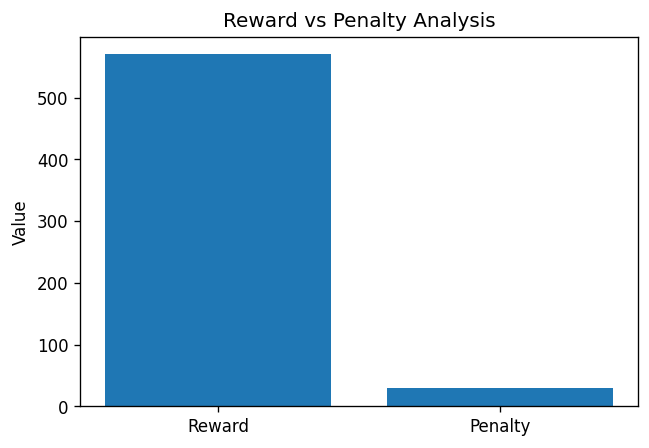

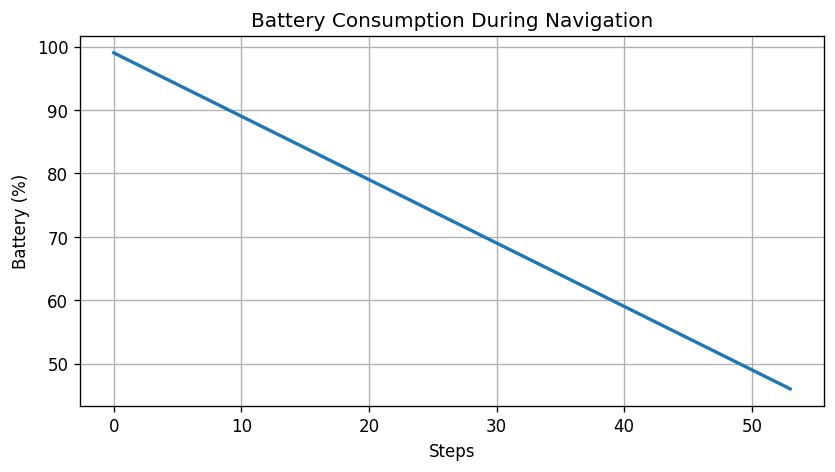

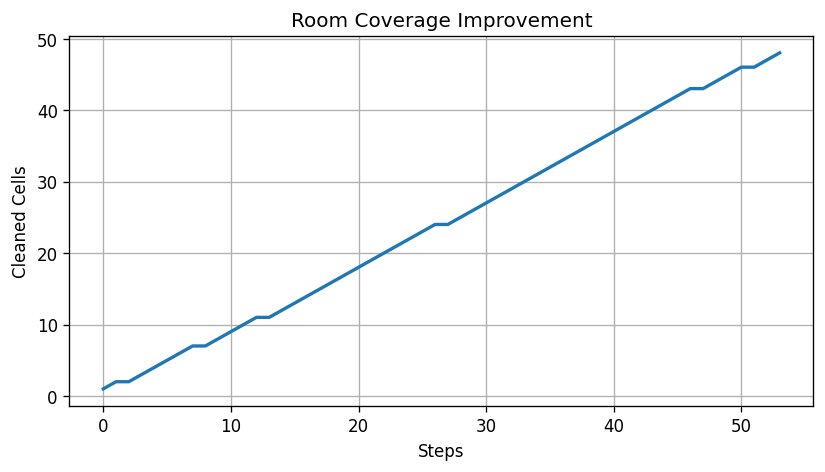

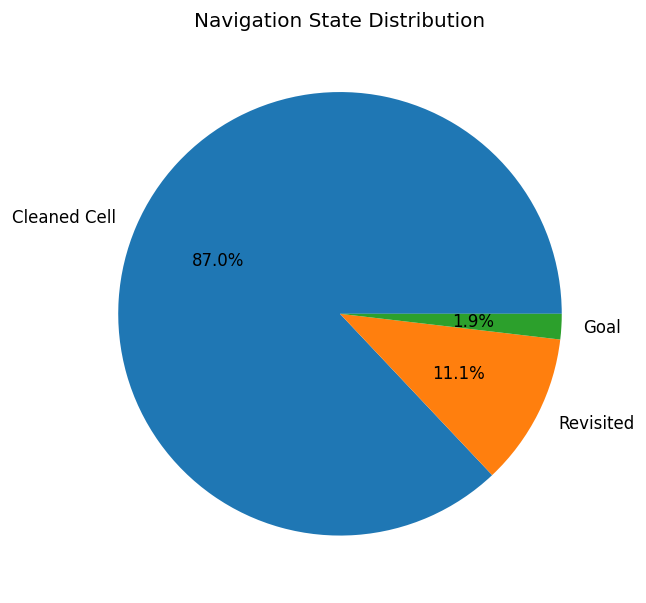

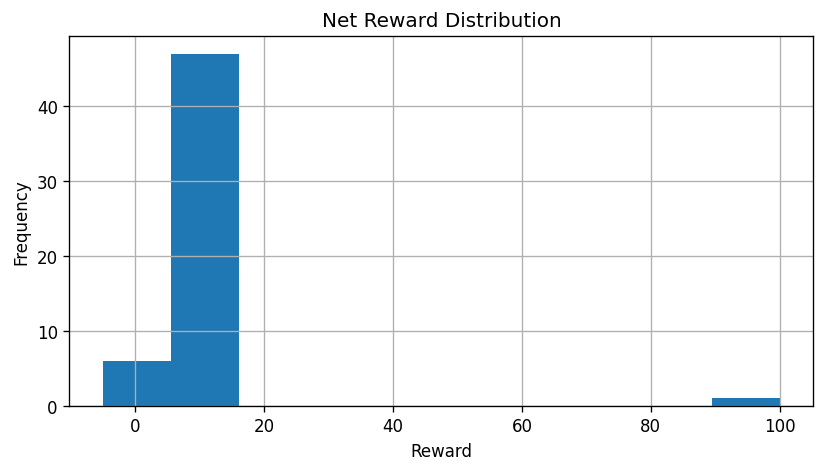

ALL VISUALIZATIONS GENERATED SUCCESSFULLY


In [ ]:
# ============================================================
# CELL 8 : PROFESSIONAL VISUALIZATION DASHBOARD
# ============================================================


# ------------------------------------------------------------
# 1. Robot Navigation Path
# ------------------------------------------------------------

plt.figure(figsize=(8,8))


plt.imshow(
    environment,
    cmap="gray_r"
)


path_x = vacuum_df["Y_Position"]
path_y = vacuum_df["X_Position"]


plt.plot(
    path_x,
    path_y,
    marker="o",
    linewidth=2
)


plt.scatter(
    START_POS[1],
    START_POS[0],
    s=150,
    label="Start"
)


plt.scatter(
    GOAL_POS[1],
    GOAL_POS[0],
    s=150,
    label="Goal"
)


plt.title("Autonomous Vacuum Cleaner Navigation Path")

plt.xlabel("Y Position")

plt.ylabel("X Position")

plt.legend()

plt.grid(True)

plt.show()



# ------------------------------------------------------------
# 2. Cumulative Reward
# ------------------------------------------------------------

plt.figure(figsize=(8,4))


plt.plot(
    vacuum_df["Step"],
    vacuum_df["Cumulative_Reward"],
    linewidth=2
)


plt.title("Cumulative Reward Over Time")

plt.xlabel("Steps")

plt.ylabel("Cumulative Reward")

plt.grid(True)

plt.show()
reward_total = vacuum_df["Reward"].sum()

penalty_total = abs(
    vacuum_df["Penalty"].sum()
)
plt.figure(figsize=(6,4))
plt.bar(
    ["Reward","Penalty"],
    [reward_total, penalty_total]
)
plt.title("Reward vs Penalty Analysis")

plt.ylabel("Value")

plt.show()



# ------------------------------------------------------------
# 4. Battery Consumption
# ------------------------------------------------------------

plt.figure(figsize=(8,4))


plt.plot(
    vacuum_df["Step"],
    vacuum_df["Battery"],
    linewidth=2
)


plt.title("Battery Consumption During Navigation")

plt.xlabel("Steps")

plt.ylabel("Battery (%)")

plt.grid(True)

plt.show()



# ------------------------------------------------------------
# 5. Coverage Improvement
# ------------------------------------------------------------

plt.figure(figsize=(8,4))


plt.plot(
    vacuum_df["Step"],
    vacuum_df["Coverage"],
    linewidth=2
)


plt.title("Room Coverage Improvement")

plt.xlabel("Steps")

plt.ylabel("Cleaned Cells")

plt.grid(True)

plt.show()



# ------------------------------------------------------------
# 6. State Distribution
# ------------------------------------------------------------

state_counts = vacuum_df["State"].value_counts()


plt.figure(figsize=(6,6))


plt.pie(
    state_counts,
    labels=state_counts.index,
    autopct="%1.1f%%"
)


plt.title("Navigation State Distribution")

plt.show()



# ------------------------------------------------------------
# 7. Reward Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8,4))


plt.hist(
    vacuum_df["Net_Reward"],
    bins=10
)


plt.title("Net Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()



# ------------------------------------------------------------
# Final Message
# ------------------------------------------------------------

print("="*70)

print("ALL VISUALIZATIONS GENERATED SUCCESSFULLY")

print("="*70)